In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style
import matplotlib as mpl
from cycler import cycler
import numpy as np

In [2]:
mpl.rcParams['axes.prop_cycle'] = cycler(color=['#007191', '#f47a00', '#62c8d3', '#c31e23', '#ff5a5e',  '#fbac2b'])
sns.set_palette(['#007191', '#f47a00', '#62c8d3', '#c31e23', '#ff5a5e', '#fbac2b'])

In [3]:
phase1 = pd.read_csv("../results/phase_1.csv")
phase2 = pd.read_csv("../results/phase_2.csv")
phase3 = pd.read_csv("../results/phase_3.csv")
phase4 = pd.read_csv("../results/phase_4.csv")
phase5 = pd.read_csv("../results/phase_5.csv")

## PHASE 1 - Methods comparison

In [4]:
phase1["method_type"] = np.where(
    phase1["method"].str.contains("dcd", case=False, na=False),
    "our implementation",
    "sklearn"
)

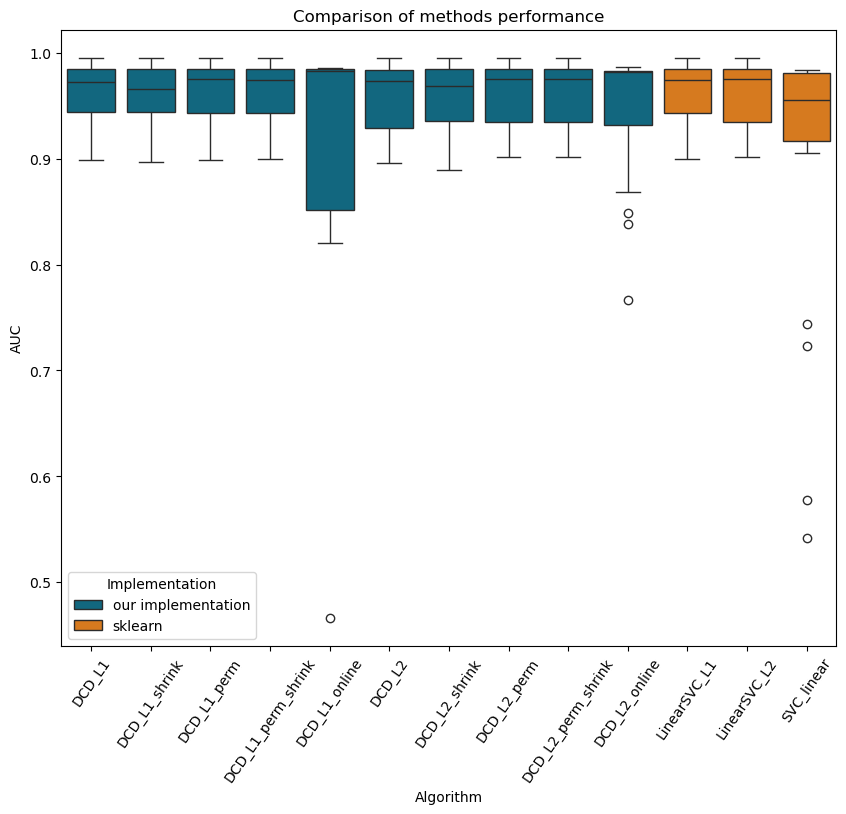

In [5]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase1, x="method", y="auc", hue="method_type")
plt.xticks(rotation=55)
plt.legend(title="Implementation")
plt.xlabel("Algorithm")
plt.ylabel("AUC")
plt.title("Comparison of methods performance")
plt.show()


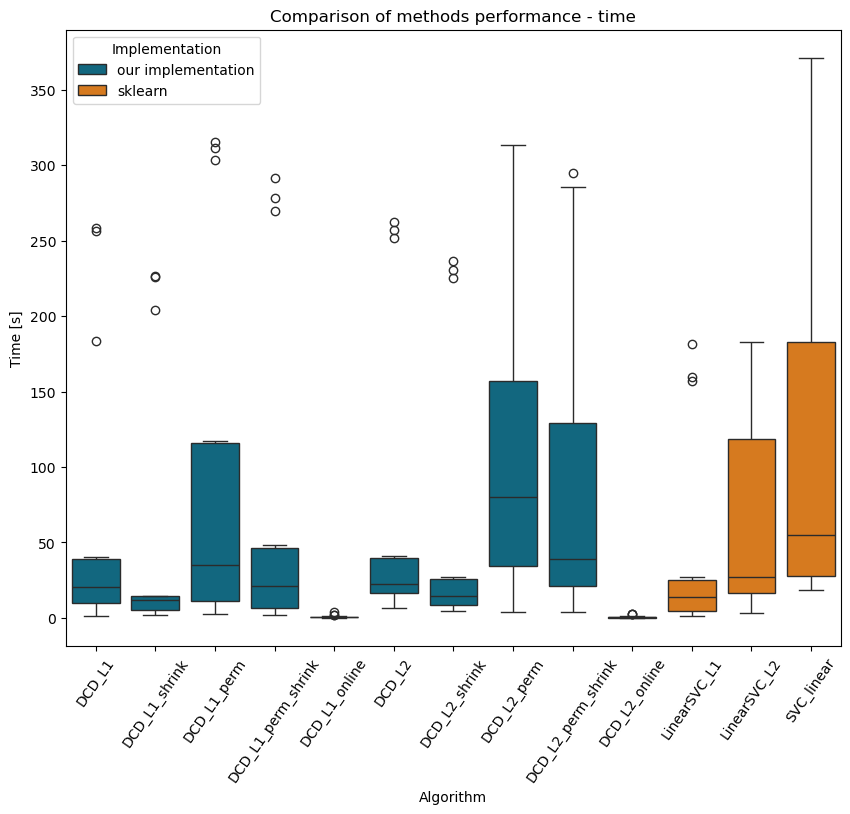

In [6]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase1, x="method", y="time_s", hue="method_type")
plt.xticks(rotation=55)
plt.legend(title="Implementation")
plt.xlabel("Algorithm")
plt.ylabel("Time [s]")
plt.title("Comparison of methods performance - time")
plt.show()

In [7]:
phase1_own = phase1[phase1["method_type"] == "our implementation"]
phase1_own["method_type"] = np.where(
    phase1_own["method"].str.contains("L1", case=False, na=False),
    "L1",
    "L2"
)
phase1_own["method"] = phase1_own["method"].str.split("_").str[2:].str.join("_")
phase1_own["method"] = phase1_own["method"].replace("", "base")

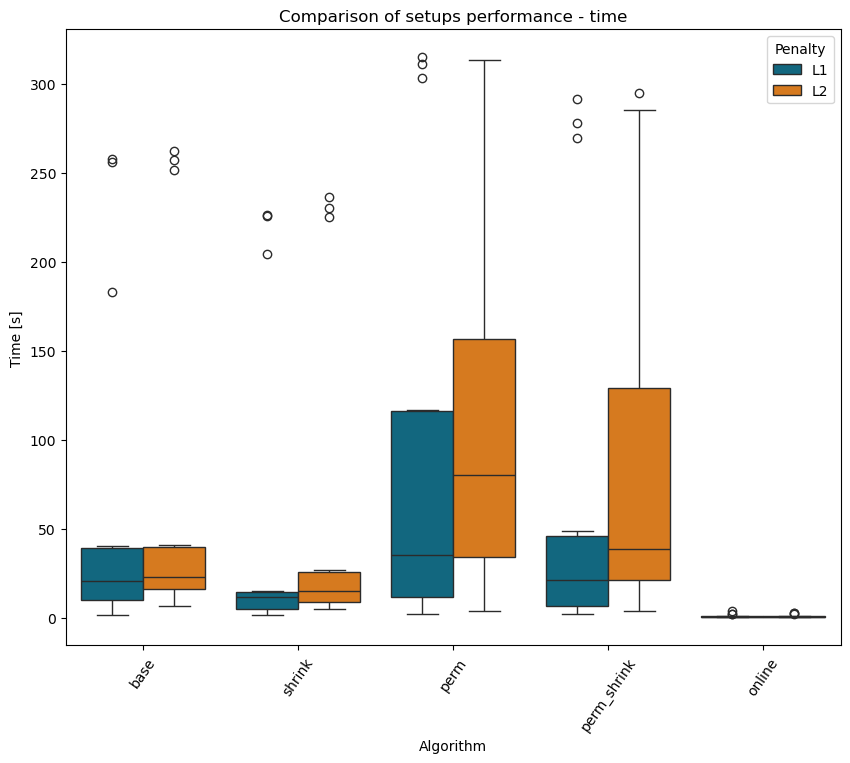

In [8]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase1_own, x="method", y="time_s", hue="method_type",)
plt.xticks(rotation=55)
plt.legend(title="Penalty")
plt.xlabel("Algorithm")
plt.ylabel("Time [s]")
plt.title("Comparison of setups performance - time")
plt.show()

## PHASE 2 - Penalty parameter C

In [9]:
phase2["method_type"] = np.where(
    phase2["method"].str.contains("dcd", case=False, na=False),
    "our implementation",
    "sklearn"
)

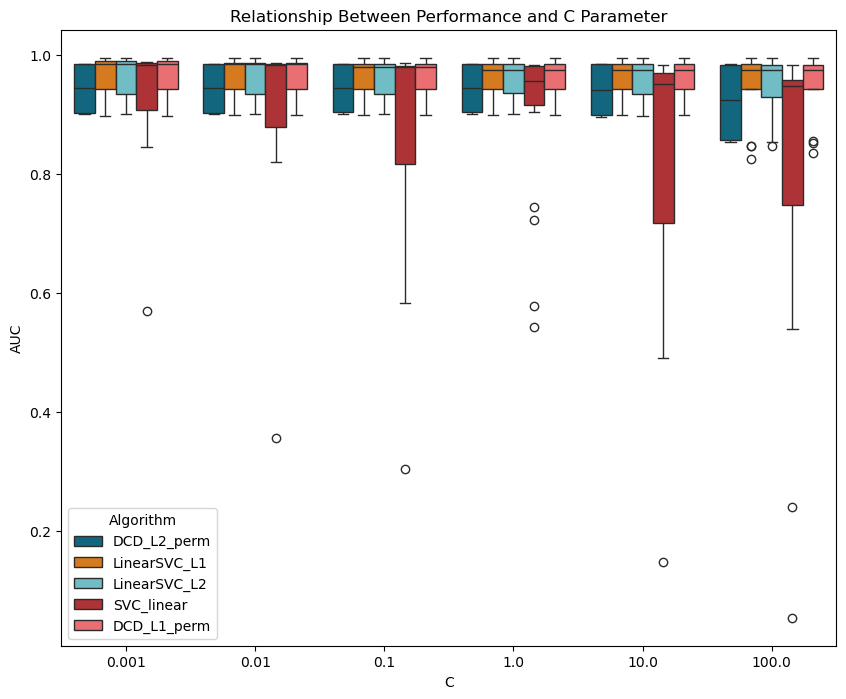

In [10]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase2, x="C", y="auc", hue="method")
plt.legend(title="Algorithm", loc="lower left")
plt.xlabel("C")
plt.ylabel("AUC")
plt.title("Relationship Between Performance and C Parameter")
plt.show()

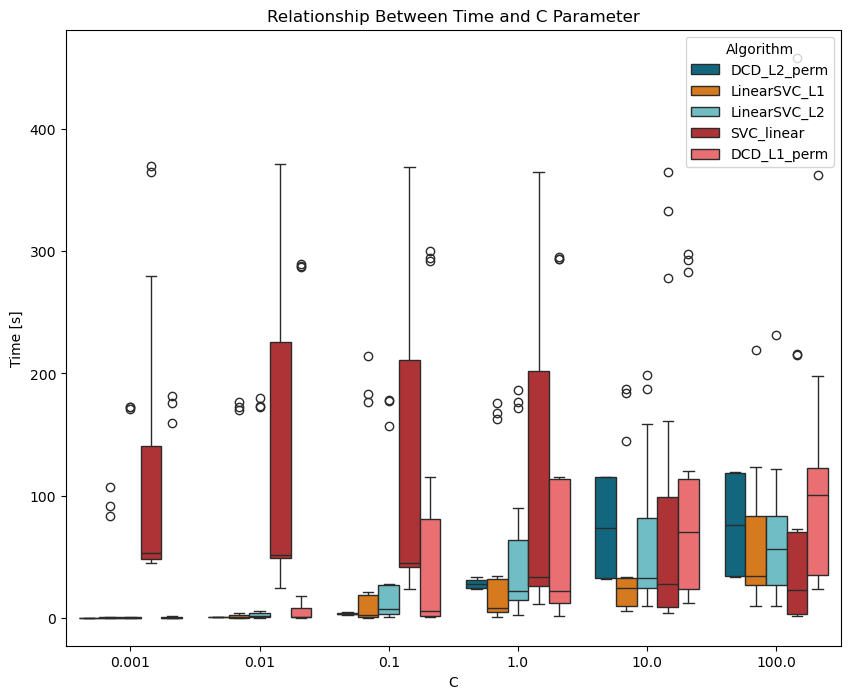

In [27]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase2, x="C", y="time_s", hue="method")
plt.legend(title="Algorithm", loc="upper right")
plt.xlabel("C")
plt.ylabel("Time [s]")
plt.title("Relationship Between Time and C Parameter")
plt.show()

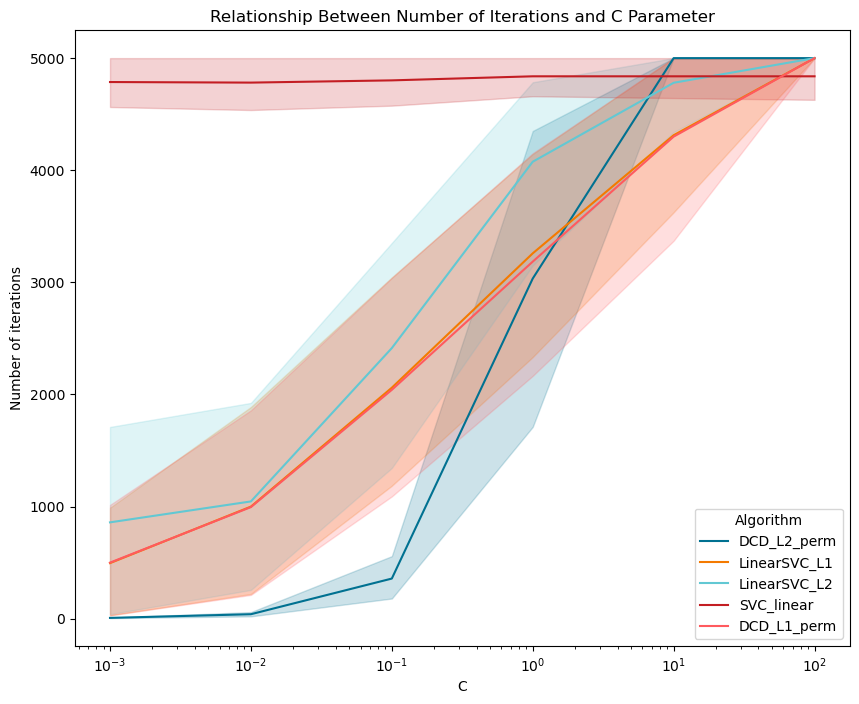

In [12]:
plt.figure(figsize=(10,8))
sns.lineplot(data=phase2, x="C", y="n_iter", hue="method")
plt.legend(title="Algorithm", loc="lower right")
plt.xlabel("C")
plt.ylabel("Number of iterations")
plt.title("Relationship Between Number of Iterations and C Parameter")
plt.xscale("log")
plt.show()

## PHASE 3 - Scalability analysis

In [28]:
phase3["time_s"] = (
    phase3["time_s"]
    .replace("Timeout >500s", 500)
    .astype(float)
)

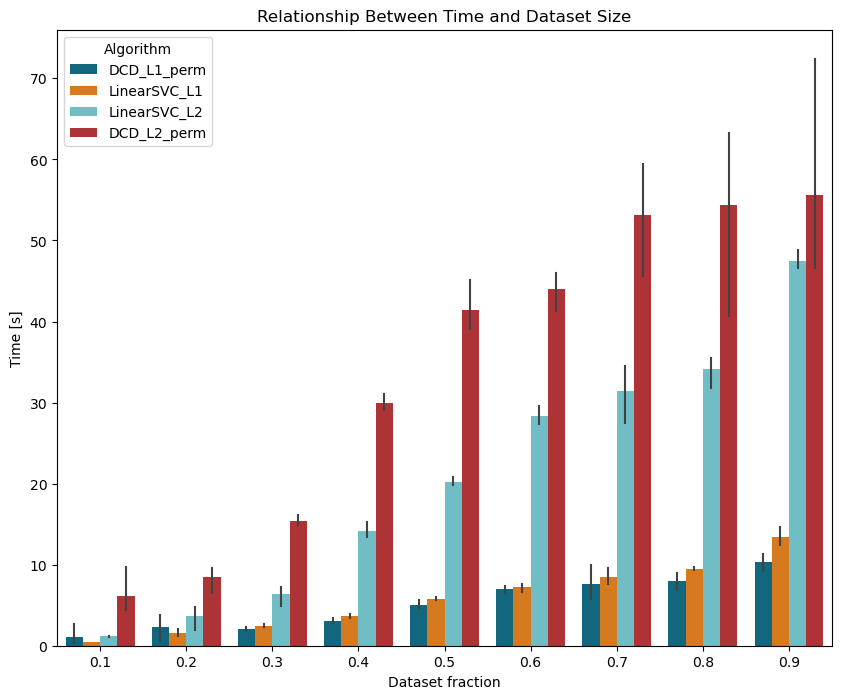

In [29]:
plt.figure(figsize=(10,8))
sns.barplot(data=phase3[phase3["method"] != "SVC_linear"], x="fraction", y="time_s", hue="method",  err_kws={"linewidth" : 1.5})
plt.legend(title="Algorithm", loc="upper left")
plt.xlabel("Dataset fraction")
plt.ylabel("Time [s]")
plt.title("Relationship Between Time and Dataset Size")
plt.show()

## PHASE 4 - Sparsity impact

In [16]:
phase4["time_s"] = (
    phase4["time_s"]
    .replace(["Timeout >500s", "Skipped (prior timeout)"], 500)
    .astype(float)
)

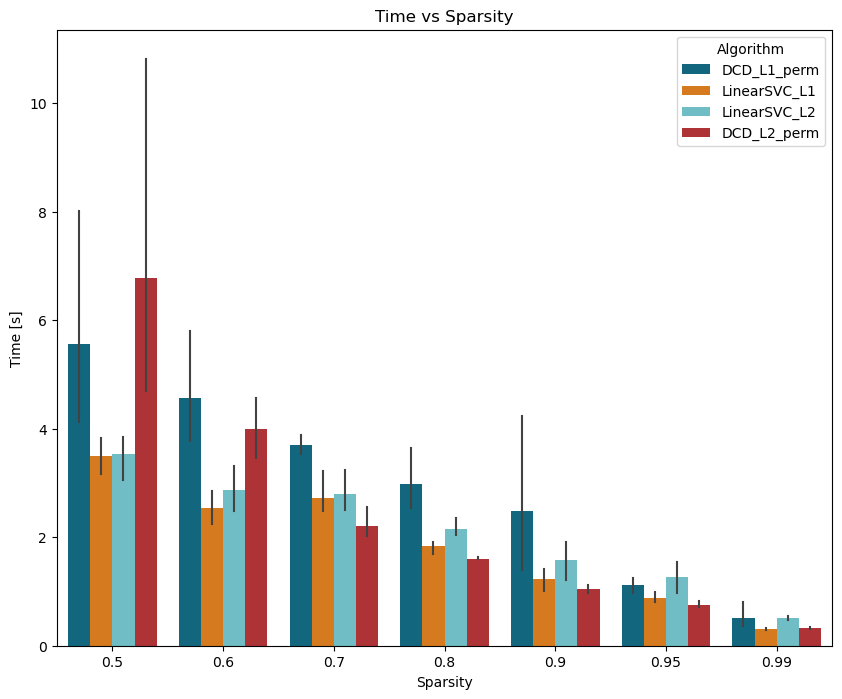

In [17]:
plt.figure(figsize=(10,8))
sns.barplot(data=phase4[phase4["method"] != "SVC_linear"], x="sparsity", y="time_s", hue="method", err_kws={"linewidth" : 1.5})
plt.legend(title="Algorithm", loc="upper right")
plt.xlabel("Sparsity")
plt.ylabel("Time [s]")
plt.title("Time vs Sparsity")
plt.show()

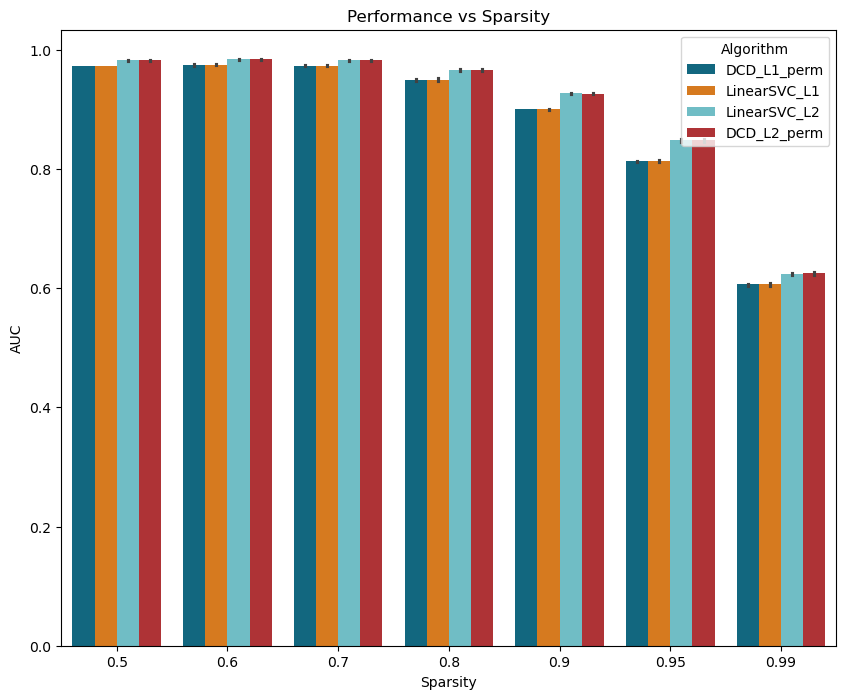

In [21]:
plt.figure(figsize=(10,8))
sns.barplot(data=phase4[phase4["method"] != "SVC_linear"], x="sparsity", y="auc", hue="method")
plt.legend(title="Algorithm", loc="upper right")
plt.xlabel("Sparsity")
plt.ylabel("AUC")
plt.title("Performance vs Sparsity")
plt.show()

## PHASE 5 - Convergence analysis

In [22]:
from data_loader import load_libsvm

class1_frac = {}
datasets = ["a9a", "cod_rna", "news20", "rcv1", "real-sim", "skin"]

for dataset in datasets:
    data_path = f"../data/{dataset}"
    X, y = load_libsvm(data_path)
    frac = np.sum(y == 1) / len(y)
    class1_frac[dataset] = frac

In [23]:
print(class1_frac)

{'a9a': np.float64(0.23928176569346055), 'cod_rna': np.float64(0.12075207642459461), 'news20': np.float64(0.5000500100020004), 'rcv1': np.float64(0.5182788262029444), 'real-sim': np.float64(0.30754124659447646), 'skin': np.float64(0.2075403173152259)}


In [24]:
df_frac = (
pd.DataFrame.from_dict(
        class1_frac,
        orient="index",
        columns=["frac"]
    )
    .reset_index()
    .rename(columns={"index": "dataset"})
)

phase5 = pd.merge(phase5, df_frac, how="right", on='dataset')

In [25]:
phase5["time_s"] = (
    phase5["time_s"]
    .replace(["Timeout >500s", "Skipped (prior timeout)"], 500)
    .astype(float)
)

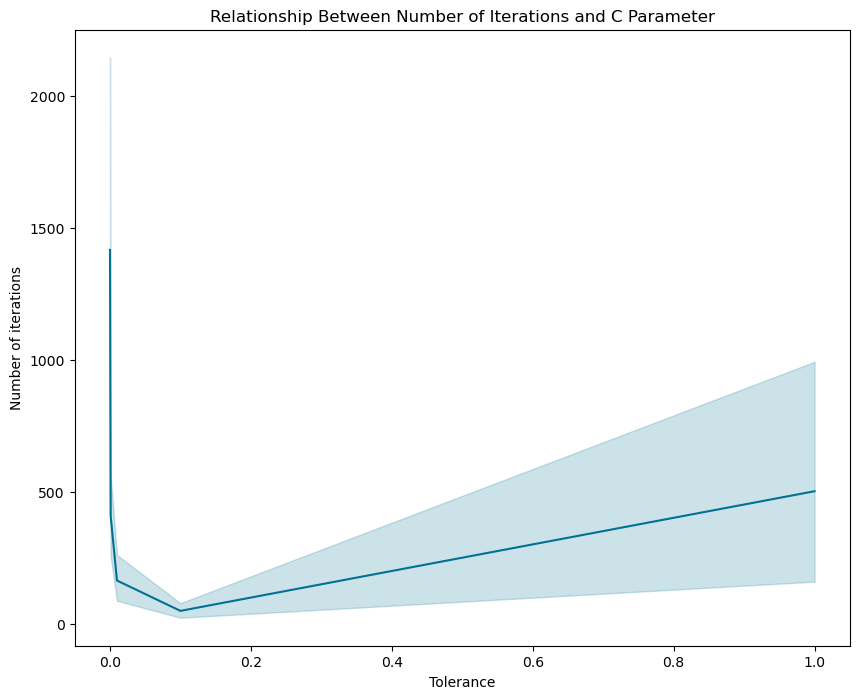

In [26]:
plt.figure(figsize=(10,8))
sns.lineplot(data=phase5, x="tol", y="n_iter")
plt.xlabel("Tolerance")
plt.ylabel("Number of iterations")
plt.title("Relationship Between Number of Iterations and C Parameter")
plt.show()